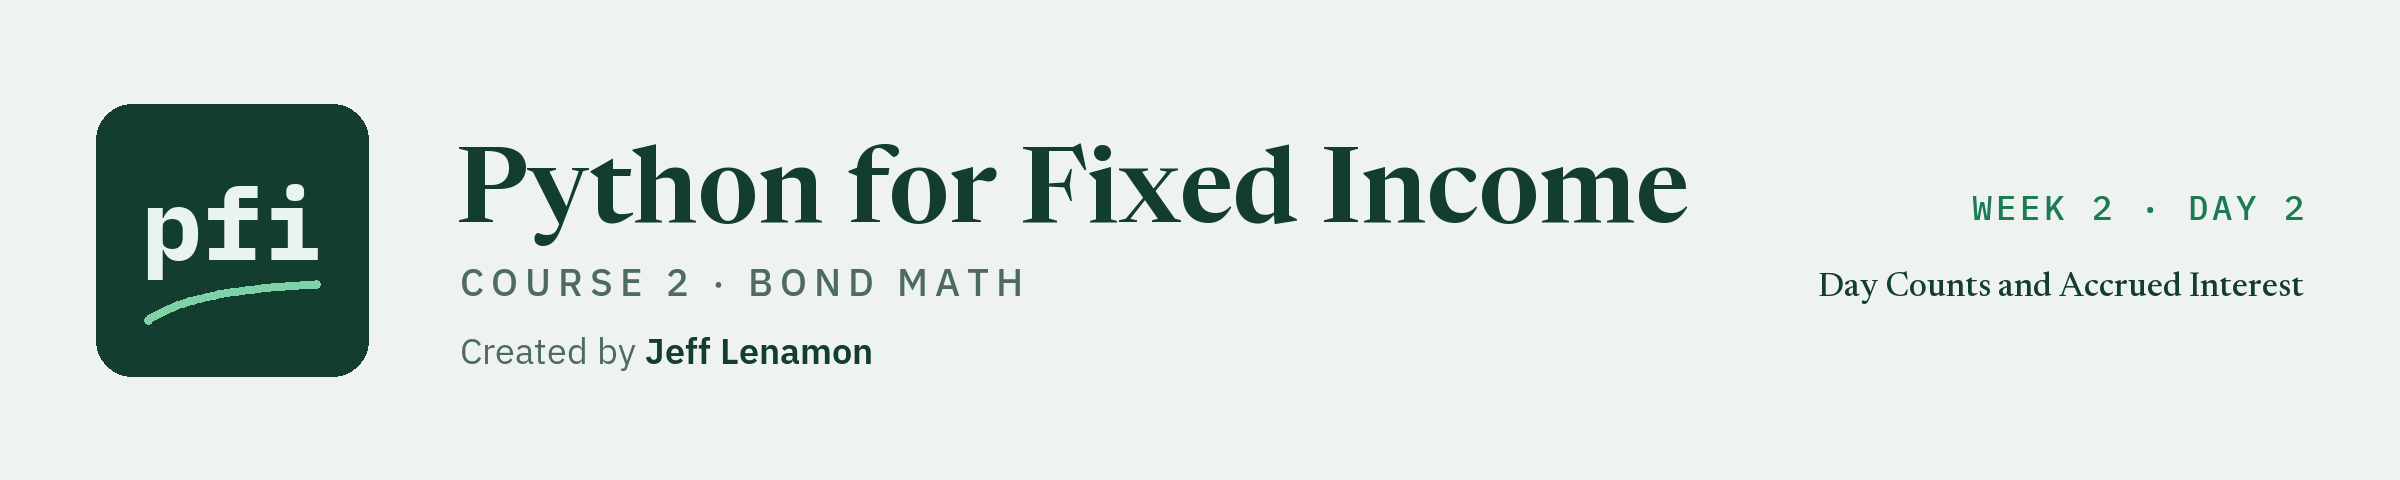

# Day Counts and Accrued Interest

Week 2, Day 2. How much interest has the seller earned on 30 November? The US 30/360 rules one at a time, actual/actual, the three day counts of a coupon period, and accrued interest, each checked against Excel, then the accrued column of the holdings file reproduced for all 200 bonds.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week2/day2/07_day_counts_and_accrued_interest.ipynb)

Yesterday found the dates around the week 2 settlement: the four bonds last paid (or started accruing) on 30 September 2026 and next pay on 31 March 2027. Today asks the first money question of the week.

**Someone buys Quorvane on Monday 30 November 2026.** On 31 March the issuer pays the whole coupon, six months of interest, to whoever holds the bond that day. The seller held it for the first two months of that period. So on 30 November the buyer pays the seller for those two months: the **accrued interest**. To compute it you need to know how many days have passed and how many days the period has, and bond markets have more than one way to count them.

Today you will:

1. See why the buyer pays accrued interest, and why two ways of counting days give two answers.
2. Learn the US 30/360 rules one at a time, each with a case Excel confirms.
3. Add `days_30_360` to your module, and meet Excel's `DAYS360`, a lookalike with different February rules.
4. Count the same period on actual/actual.
5. Add `coupon_period_days`, which returns A, E, and DSC, the three day counts of a coupon period, against Excel's `COUPDAYBS`, `COUPDAYS`, and `COUPDAYSNC`.
6. Add `accrued_interest`, against Excel's accrued formula and `ACCRINT`.
7. Reproduce the `accrued` column of the holdings file for all 200 bonds.

The issuers are invented, and so is every number. Nothing here says a bond or an issuer is good or bad.

The setup is the same as yesterday's. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 6.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_07_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_07_uix_thvf, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates']


* The two files exactly as day 6 left them: eight functions and 15 tests. By the end of today there will be eleven functions.

Record the starting point in Git first.

Q. Make the work folder a repository and commit the start-of-day files.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_07_uix_thvf and nowhere else


In [7]:
# choose the two files, commit them quietly, and show the history
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 7: bondmath.py and test_bondmath.py as day 6 left them"
!git -C "{work}" log --oneline

be95c63 Start of day 7: bondmath.py and test_bondmath.py as day 6 left them


* One commit, the start of day 7. Its hash changes on every run.

Q. Type in the four bonds and the settlement date.

In [8]:
from datetime import date

bonds = pd.DataFrame({
    "cusip": ['99001BZA7', '99002CZA4', '99003DZA1', '99004EZA8'],
    "issuer": ['Quorvane Energy', 'Dunmarrow Rail', 'Pellwick Paper', 'Halvering Foods'],
    "ticker": ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    "coupon_pct": [5.25, 6.125, 4.75, 7.5],
    "maturity": [date(2031, 9, 30), date(2033, 9, 30), date(2029, 9, 30), date(2036, 9, 30)],
})
settlement = date(2026, 11, 30)

bonds

,cusip,issuer,ticker,coupon_pct,maturity
0,99001BZA7,Quorvane Energy,QVNE,5.250,2031-09-30
1,99002CZA4,Dunmarrow Rail,DNMR,6.125,2033-09-30
2,99003DZA1,Pellwick Paper,PLWK,4.750,2029-09-30
3,99004EZA8,Halvering Foods,HLVF,7.500,2036-09-30


* The same four bonds, with the maturities typed as dates this time. All four share the previous coupon, 30 September 2026, and the next, 31 March 2027.

## 7.1 Why the Buyer Pays Accrued Interest

A bond's coupon is paid in whole on the coupon date, to whoever holds the bond. Interest is earned day by day in between. When a bond changes hands between two coupons, the buyer will collect the whole next coupon, including the part earned while the seller held it. So the buyer pays the seller that part at settlement. That payment is accrued interest, and it is paid on top of the quoted price. Day 8 builds the price; today is the accrued.

Accrued interest is one coupon times the share of the coupon period that has passed:

accrued = coupon_pct / frequency x (days accrued) / (days in the period)

Q. What share of Quorvane's coupon period has passed on 30 November, counting calendar days?

In [9]:
previous_coupon = date(2026, 9, 30)
next_coupon = date(2027, 3, 31)

# calendar days: the seller's days, and the whole period
days_held = (settlement - previous_coupon).days
days_in_period = (next_coupon - previous_coupon).days

# one coupon per 100 of face, then the share of it earned so far
coupon_per_period = 5.25 / 2
accrued_actual = coupon_per_period * days_held / days_in_period
print(f"{days_held} of {days_in_period} days: accrued {accrued_actual:.6f} per 100")

61 of 182 days: accrued 0.879808 per 100


* 61 calendar days out of 182, so 0.879808 per 100 of face.

Q. Now count the same stretch the 30/360 way: every month 30 days, every period 180 days.

In [10]:
# 30 September to 30 November: two months of 30 days
days_held_30 = 2 * 30
accrued_30 = coupon_per_period * days_held_30 / 180
print(f"{days_held_30} of 180 days: accrued {accrued_30:.6f} per 100")

# Excel's accrued for Quorvane on 30 November, from the week 2 rows of the reference file
reference = pd.read_csv("bondmath_excel_reference.csv")
week2 = reference[reference["group"] == "week2"].set_index("case_id")
print(f"Excel's accrued for Quorvane:  {week2.loc['99001BZA7', 'accrued']:.6f} per 100")

60 of 180 days: accrued 0.875000 per 100
Excel's accrued for Quorvane:  0.875000 per 100


* Two counts, two answers: 0.879808 on calendar days, 0.875000 on 30/360. Excel's number is 0.875000, the 30/360 one.
* Neither count is a mistake. Each bond's documents name a **day count convention**, and the course's bonds, like US corporate bonds generally, use 30/360. On 1,000,000 dollars of face, 0.875 per 100 is 8,750.00 dollars the buyer pays the seller.
* So "how many days" is a convention, not a fact of the calendar. The rest of today makes both conventions exact.

## 7.2 The 30/360 Rules, One at a Time

30/360 pretends every month has 30 days. With D1 and D2 the day numbers of the start and end dates, the count is:

Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1)

Before the formula, the US 30/360 basis (the one Excel's `COUPDAYBS` uses with basis 0) changes D1 and D2 near the end of a month. There are four rules:

1. If the start is the **last day of February**, D1 = 30.
2. If the start and the end are **both the last day of February**, D2 = 30.
3. If D1 is **31**, D1 = 30.
4. If D2 is **31** and the start date's day was **30 or 31**, D2 = 30.

One rule at a time, each with a pair of dates. Every count below is one Excel returned, and each line says where.

Q. Write the formula as a small helper that takes the day numbers after the rules.

In [11]:
def count_30_360(start, end, d1, d2):
    """The 30/360 formula, given D1 and D2 after the rules."""
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


# no rule needed: 16 August to 30 September 2026
start, end = date(2026, 8, 16), date(2026, 9, 30)
print(f"{start} to {end}: {count_30_360(start, end, start.day, end.day)} days (calendar: {(end - start).days})")

2026-08-16 to 2026-09-30: 44 days (calendar: 45)


* 44 days: one month of 30, plus 30 - 16. The calendar says 45, because August has 31 days.
* Excel: 16 August is the previous coupon of the holdings bond `99120QAD1` on 30 September, and `=COUPDAYBS(DATE(2026,9,30),DATE(2036,2,16),2,0)` returns 44.

Q. Rule 1: from the last day of February to 1 March 2027.

In [12]:
start, end = date(2027, 2, 28), date(2027, 3, 1)
print(f"no rule:     {count_30_360(start, end, start.day, end.day)} days")
# rule 1: the last day of February counts as the 30th
print(f"rule 1:      {count_30_360(start, end, 30, end.day)} day")

no rule:     3 days
rule 1:      1 day


* Without the rule, 3 days for one night. Rule 1 treats 28 February as the 30th, so the count is 1, as the calendar says.
* Excel: the edge row `edge_settle_1_mar_after_feb_end` has its previous coupon on 28 February 2027, and `=COUPDAYBS(DATE(2027,3,1),DATE(2031,8,31),2,0)` returns 1.

Q. Rule 2: from the last day of February 2027 to the last day of February 2028.

In [13]:
start, end = date(2027, 2, 28), date(2028, 2, 29)
# rule 1 alone: the start counts as the 30th, the end stays 29
print(f"rule 1 only: {count_30_360(start, end, 30, end.day)} days")
# rule 2: both on the last day of February, so the end counts as the 30th too
print(f"rule 2:      {count_30_360(start, end, 30, 30)} days")

rule 1 only: 359 days
rule 2:      360 days


* One year from one February month end to the next is 360 days with rule 2, and 359 with rule 1 alone.
* Excel: no coupon period runs from one February month end to another, so `COUPDAYBS` never meets rule 2. `YEARFRAC` with basis 0 does: `=YEARFRAC(DATE(2027,2,28),DATE(2028,2,29),0)*360` returns 360 (tested).

Q. Rule 3: from 31 August to 30 September 2026.

In [14]:
start, end = date(2026, 8, 31), date(2026, 9, 30)
print(f"no rule:     {count_30_360(start, end, start.day, end.day)} days")
# rule 3: a 31st start counts as the 30th
print(f"rule 3:      {count_30_360(start, end, 30, end.day)} days")

no rule:     29 days
rule 3:      30 days


* One month is 30 days, as 30/360 promises, not 29.
* Excel: `edge_mat_aug_31` matures on 31 August, so its previous coupon on 30 September 2026 is 31 August, and `=COUPDAYBS(DATE(2026,9,30),DATE(2031,8,31),2,0)` returns 30.

Q. Rule 4: from 30 July to 31 October 2026, and from 15 October to 31 October.

In [15]:
start, end = date(2026, 7, 30), date(2026, 10, 31)
print(f"no rule:     {count_30_360(start, end, start.day, end.day)} days")
# rule 4: a 31st end counts as the 30th, because the start day is 30
print(f"rule 4:      {count_30_360(start, end, start.day, 30)} days")

# a 15th start: rule 4 does not apply, and the 31st stays 31
start, end = date(2026, 10, 15), date(2026, 10, 31)
print(f"15th to 31st: {count_30_360(start, end, start.day, end.day)} days")

no rule:     91 days
rule 4:      90 days
15th to 31st: 16 days


* Three months from the 30th is 90 days. From the 15th to the 31st is 16: the 31st only becomes the 30th when the start was already at the end of its month.
* Excel: `=COUPDAYBS(DATE(2026,10,31),DATE(2031,7,30),2,0)` returns 90 (row `edge_settle_31_oct_mat_30_jul`), and `=COUPDAYBS(DATE(2026,10,31),DATE(2032,4,15),2,0)` returns 16 (row `edge_settle_31_oct_mat_15`).

Q. Two traps. From 28 February to 31 March 2027, does rule 4 apply? And from 15 November 2026 to 28 February 2027, does anything happen to the end?

In [16]:
# rule 1 makes D1 = 30, but rule 4 looks at the start date's own day, 28, so the 31st stays 31
start, end = date(2027, 2, 28), date(2027, 3, 31)
print(f"{start} to {end}: {count_30_360(start, end, 30, end.day)} days")

# an end on the last day of February is not changed (rules 1 and 2 are about the start)
start, end = date(2026, 11, 15), date(2027, 2, 28)
print(f"{start} to {end}: {count_30_360(start, end, start.day, end.day)} days (calendar: {(end - start).days})")

2027-02-28 to 2027-03-31: 31 days
2026-11-15 to 2027-02-28: 103 days (calendar: 105)


* 31 days, not 30. Rule 4 asks about the start date as it is on the calendar, the 28th, not D1 after rule 1. This is how Excel counts: `=COUPDAYBS(DATE(2027,3,31),DATE(2031,8,31),2,0)` returns 31 (row `edge_settle_31_mar_after_feb_end`). Excel's own `DAYS360`, in the next section, looks at D1 after rule 1 instead; the course follows `COUPDAYBS`.
* 103 days to 28 February, where the calendar says 105. Nothing changes D2 here, so a 30/360 period ending on 28 February comes up short. Excel: `=COUPDAYBS(DATE(2027,2,28),DATE(2032,5,15),2,0)` returns 103.
* Every rule is about the end of a month. In the middle of a month, 30/360 is just the formula.

## 7.3 `days_30_360`

Q. Add `days_30_360` to the end of `bondmath.py`. Read it before you run the cell.

In [17]:
%%writefile -a bondmath.py


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)

Appending to bondmath.py


* The docstring states the four rules, the formula, and the two Excel functions that count this way. It also warns that `DAYS360` is a different count; more on that below.
* Two flags first: is the start, and is the end, the last day of February? `calendar.monthrange`, from day 6, gives February's length in that year. Then the rules in order, each on its own line, then the formula.
* Rule 4 tests `start.day`, the date's own day, not `d1`. That one word is the trap of the last section.

Q. Add the first test: one row per rule, each value confirmed by Excel.

In [18]:
%%writefile -a test_bondmath.py


BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel's basis number to bondmath's name


def bond_inputs(row: dict) -> tuple:
    """settlement, maturity, coupon_pct, yield_pct, frequency, basis from a reference row, in bondmath's units."""
    return (date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"]),
            float(row["coupon_pct"]), float(row["yield_pct"]), int(row["frequency"]), BASIS[row["basis"]])


def test_days_30_360_rule_cases():
    # (start, end, expected days, the Excel function that confirms the value)
    cases = [
        (date(2026, 8, 16), date(2026, 9, 30), 44, "COUPDAYBS"),    # no rule applies
        (date(2027, 2, 28), date(2027, 3, 1), 1, "COUPDAYBS"),      # rule 1: last day of February counts as 30
        (date(2027, 2, 28), date(2028, 2, 29), 360, "YEARFRAC"),    # rule 2: both on the last day of February
        (date(2026, 8, 31), date(2026, 9, 30), 30, "COUPDAYBS"),    # rule 3: a 31st start counts as 30
        (date(2026, 7, 30), date(2026, 10, 31), 90, "COUPDAYBS"),   # rule 4: a 31st end after a 30th start
        (date(2026, 10, 15), date(2026, 10, 31), 16, "COUPDAYBS"),  # a 31st end after a 15th start stays 31
        (date(2027, 2, 28), date(2027, 3, 31), 31, "COUPDAYBS"),    # rule 1, and the 31st end stays 31
        (date(2026, 11, 15), date(2027, 2, 28), 103, "COUPDAYBS"),  # an end on 28 February is not changed
    ]
    for start, end, expected, source in cases:
        assert bondmath.days_30_360(start, end) == expected, (start, end)
        if source == "COUPDAYBS":
            # the same pair of dates appears in the reference file as previous coupon and settlement
            matches = [row for row in REFERENCE if row["basis"] == "0" and row["couppcd"] == start.isoformat()
                       and row["settlement"] == end.isoformat()]
            assert matches, f"no reference row with previous coupon {start} and settlement {end}"
            assert int(matches[0]["coupdaybs"]) == expected
        # the YEARFRAC value, YEARFRAC(start, end, 0) x 360 = 360, was checked in Excel by the reference tool

Appending to test_bondmath.py


* `BASIS` and `bond_inputs` are helpers for today's other two tests: they turn a reference row's text into `bondmath`'s units, and Excel's basis number into the course's basis name.
* The rule test is the hand table of section 7.2. For each `COUPDAYBS` case it also finds the reference row with that previous coupon and settlement, and checks Excel's value is the one in the table. So the hand table cannot drift away from Excel.

Q. Reload, and run `days_30_360` on the cases of section 7.2.

In [19]:
importlib.reload(bondmath)

cases = [(date(2026, 8, 16), date(2026, 9, 30)), (date(2027, 2, 28), date(2027, 3, 1)),
         (date(2027, 2, 28), date(2028, 2, 29)), (date(2026, 8, 31), date(2026, 9, 30)),
         (date(2026, 7, 30), date(2026, 10, 31)), (date(2026, 10, 15), date(2026, 10, 31)),
         (date(2027, 2, 28), date(2027, 3, 31)), (date(2026, 11, 15), date(2027, 2, 28))]
rows = [{"start": s, "end": e, "days_30_360": bondmath.days_30_360(s, e), "calendar_days": (e - s).days} for s, e in cases]
pd.DataFrame(rows)

,start,end,days_30_360,calendar_days
0,2026-08-16,2026-09-30,44,45
1,2027-02-28,2027-03-01,1,1
2,2027-02-28,2028-02-29,360,366
3,2026-08-31,2026-09-30,30,30
4,2026-07-30,2026-10-31,90,93
5,2026-10-15,2026-10-31,16,16
6,2027-02-28,2027-03-31,31,31
7,2026-11-15,2027-02-28,103,105


* The function gives every count of section 7.2: 44, 1, 360, 30, 90, 16, 31, 103. The calendar column shows how far 30/360 can sit from the calendar near month ends.

Q. Quorvane, from the previous coupon to settlement.

In [20]:
print(f"30/360 days from 30 September to 30 November: {bondmath.days_30_360(date(2026, 9, 30), settlement)}")

30/360 days from 30 September to 30 November: 60


* 60, the count of section 7.1. Neither date is near a rule, so it is the plain formula.

**Excel side by side: `DAYS360`, a lookalike.** Excel has a function whose name sounds like this one, `DAYS360(start_date, end_date)`. Without its optional third argument it uses its US method, and it is not the count `COUPDAYBS` uses. Tested in Excel, where `YEARFRAC(start, end, 0)*360` gives `COUPDAYBS`'s rules: `=DAYS360(DATE(2027,2,28),DATE(2028,2,29))` returns 359 where `=YEARFRAC(DATE(2027,2,28),DATE(2028,2,29),0)*360` returns 360; `=DAYS360(DATE(2026,2,28),DATE(2026,10,31))` returns 240 where `YEARFRAC` gives 241; and `=DAYS360(DATE(2027,2,28),DATE(2027,2,28))`, the same date twice, returns -2. `DAYS360` has its own February rules: it treats a February month-end start as the 30th, never applies rule 2, and turns a 31st end into the 30th when D1, after that change, is 30. Away from February month ends the two agree. Both are 30/360 counts; the course uses the one `COUPDAYBS` and `PRICE` use.

Q. `days_30_360` on those three pairs, beside the two Excel functions.

In [21]:
# DAYS360 and YEARFRAC(...,0)*360 as Excel returned them (tested in Excel; typed here, not computed)
pairs = [(date(2027, 2, 28), date(2028, 2, 29), 359, 360),
         (date(2026, 2, 28), date(2026, 10, 31), 240, 241),
         (date(2027, 2, 28), date(2027, 2, 28), -2, 0)]
rows = [{"start": s, "end": e, "excel_days360": d360, "excel_yearfrac_x_360": yf, "days_30_360": bondmath.days_30_360(s, e)}
        for s, e, d360, yf in pairs]
lookalike = pd.DataFrame(rows)
assert (lookalike["days_30_360"] == lookalike["excel_yearfrac_x_360"]).all()
lookalike

,start,end,excel_days360,excel_yearfrac_x_360,days_30_360
0,2027-02-28,2028-02-29,359,360,360
1,2026-02-28,2026-10-31,240,241,241
2,2027-02-28,2027-02-28,-2,0,0


* `days_30_360` equals `YEARFRAC` times 360 on all three, and differs from `DAYS360` on all three. Every pair starts on a February month end.
* None of today's bonds starts a period on a February month end, so `DAYS360` would give their accrued correctly. The difference shows up on bonds that pay at the end of February, which is exactly where a lookalike is most likely to be trusted without a check.

## 7.4 Actual/Actual

The other day count in this course is **actual/actual**, the way US Treasuries count. Days accrued are calendar days, and the days in the period are the calendar length of that coupon period, so a period from 30 September to 31 March has 182 days, and one that holds a 29 February has 183. Excel calls it basis 1, and `bondmath` calls it `"ACT/ACT"`.

Q. Quorvane on 30 November, counted actual/actual: days accrued, days in the period, and the accrued.

In [22]:
quorvane_maturity = date(2031, 9, 30)
dates = bondmath.coupon_dates(settlement, quorvane_maturity)

# every count is calendar days
days_accrued_act = (settlement - dates[0]).days
days_in_period_act = (dates[1] - dates[0]).days
accrued_act = 5.25 / 2 * days_accrued_act / days_in_period_act
print(f"actual/actual: {days_accrued_act} of {days_in_period_act} days, accrued {accrued_act:.6f} per 100")
print(f"30/360:        60 of 180 days, accrued {5.25 / 2 * 60 / 180:.6f} per 100")

actual/actual: 61 of 182 days, accrued 0.879808 per 100
30/360:        60 of 180 days, accrued 0.875000 per 100


* 61 of 182 days, 0.879808, the calendar count of section 7.1. On the same bond and date the two conventions differ by 0.004808 per 100, 48.08 dollars on 1,000,000 of face. Small, and on a large trade it is real money paid to the wrong party.
* The course's bonds are 30/360. Actual/actual is here because the functions take a `basis` argument, and because getting it wrong is today's AI check.

**Excel side by side: `COUPDAYBS` and `COUPDAYS` with basis 1.** `COUPDAYBS` with basis 1 counts actual days: for the reference row `act_mat_apr_30`, `=COUPDAYBS(DATE(2026,9,30),DATE(2031,4,30),2,1)` returns 153, the calendar days from 30 April 2026 to 30 September 2026, where 30/360 counts 150. `COUPDAYS` with basis 1 is not always the calendar length of the period. The reference row `act_coupon_date_5y` has the same coupon period as today's bonds, 30 September 2026 to 31 March 2027, 182 days, and `=COUPDAYS(DATE(2026,9,30),DATE(2031,9,30),2,1)` returns 181. Excel's `PRICE` uses the calendar length (tested), so the course takes E under actual/actual as `COUPNCD - COUPPCD`, not `COUPDAYS`.

Q. How often does `COUPDAYS` with basis 1 differ from the calendar length of the period in the reference file?

In [23]:
basis1 = reference[reference["basis"] == 1].copy()
# the calendar length of each row's coupon period, from Excel's own COUPPCD and COUPNCD
basis1["period_days"] = (pd.to_datetime(basis1["coupncd"]) - pd.to_datetime(basis1["couppcd"])).dt.days
differ = basis1[basis1["coupdays"] != basis1["period_days"]]
print(f"basis 1 rows: {len(basis1)}, COUPDAYS differs from the period's length in {len(differ)}")
differ[["case_id", "couppcd", "coupncd", "period_days", "coupdays"]].head(6)

basis 1 rows: 28, COUPDAYS differs from the period's length in 12


,case_id,couppcd,coupncd,period_days,coupdays
266,act_coupon_date_5y,2026-09-30,2027-03-31,182,181
272,act_settle_31_mar_after_feb_end,2027-02-28,2027-08-31,184,181
274,act_mat_feb_28_leap_not_month_end,2026-08-28,2027-02-28,184,181
275,act_mat_mar_31,2026-09-30,2027-03-31,182,181
276,act_mat_apr_30,2026-04-30,2026-10-31,184,183
277,act_mat_30_may_settle_coupon_date,2026-05-30,2026-11-30,184,182


* 12 of the 28 basis 1 rows, by 1 to 3 days, mostly where a coupon falls on the 29th to the 31st or on a February month end. Excel's own `PRICE`, `DURATION`, and `YIELD` use the period's calendar length, so that is the answer key for E under actual/actual.

## 7.5 A, E, and DSC, and `coupon_period_days`

Every calculation between coupons needs three day counts of the coupon period that holds settlement. The course uses Excel's letters:

* **A**: days from the previous coupon to settlement, the days accrued. Excel: `COUPDAYBS`.
* **E**: days in the coupon period. Under 30/360 it is always 360 / frequency, 180 for a semiannual bond (Excel: `COUPDAYS`). Under actual/actual it is the calendar length of the period.
* **DSC**: days from settlement to the next coupon. Day 8 discounts the cash flows over this stretch.

Under 30/360 the course takes DSC = E - A, what is left of the period. The reason is Excel's `PRICE`: it uses E - A, tested on every basis 0 row of the reference file. Under actual/actual DSC is the calendar days to the next coupon.

Q. Add `coupon_period_days` to the end of `bondmath.py`. Read it before you run the cell.

In [24]:
%%writefile -a bondmath.py


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next

Appending to bondmath.py


* It returns a tuple of three whole numbers, (A, E, DSC), and its docstring says which Excel function each one mirrors.
* A check that stops: a basis other than the two the course uses. `coupon_dates` already checks the frequency and the dates.
* Under 30/360, A comes from `days_30_360`, E is `360 // frequency`, and DSC is E - A. Under actual/actual, all three are date subtractions.

Q. Reload, and run it on Quorvane in both bases.

In [25]:
importlib.reload(bondmath)

for basis in ["30/360", "ACT/ACT"]:
    days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, quorvane_maturity, 2, basis)
    print(f"{basis:7}: A = {days_accrued}, E = {days_in_period}, DSC = {days_to_next}")

excel = week2.loc["99001BZA7"]
print(f"Excel  : COUPDAYBS {excel['coupdaybs']}, COUPDAYS {excel['coupdays']}, COUPDAYSNC {excel['coupdaysnc']}")

30/360 : A = 60, E = 180, DSC = 120
ACT/ACT: A = 61, E = 182, DSC = 121
Excel  : COUPDAYBS 60, COUPDAYS 180, COUPDAYSNC 120


* 30/360: A = 60, E = 180, DSC = 120. Actual/actual: 61, 182, 121. In each basis A + DSC = E.
* Excel's three functions, with basis 0, return 60, 180, and 120: the 30/360 line.

**Excel side by side: `COUPDAYBS`, `COUPDAYS`, `COUPDAYSNC`.** They take the same four arguments as yesterday's `COUP` functions: settlement, maturity, frequency, basis. Tested in Excel: `=COUPDAYBS(DATE(2026,11,30),DATE(2031,9,30),2,0)` returns 60, `=COUPDAYS(DATE(2026,11,30),DATE(2031,9,30),2,0)` returns 180, and `=COUPDAYSNC(DATE(2026,11,30),DATE(2031,9,30),2,0)` returns 120. Here `COUPDAYSNC` equals E - A. It does not always.

Q. In the basis 0 rows of the reference file, where does `COUPDAYSNC` differ from E - A?

In [26]:
basis0 = reference[reference["basis"] == 0].copy()
basis0["e_minus_a"] = basis0["coupdays"] - basis0["coupdaybs"]
nc_differ = basis0[basis0["coupdaysnc"] != basis0["e_minus_a"]]
print(f"basis 0 rows: {len(basis0)}, COUPDAYSNC differs from E - A in {len(nc_differ)}")
nc_differ[["case_id", "settlement", "couppcd", "coupncd", "coupdaybs", "coupdays", "e_minus_a", "coupdaysnc"]]

basis 0 rows: 278, COUPDAYSNC differs from E - A in 7


,case_id,settlement,couppcd,coupncd,coupdaybs,coupdays,e_minus_a,coupdaysnc
101,99031FAF8,2026-09-30,2026-08-28,2027-02-28,32,180,148,150
213,edge_settle_feb_27_nonleap,2027-02-27,2026-08-28,2027-02-28,179,180,1,3
219,edge_settle_oct_30_mat_feb_28_leap,2026-10-30,2026-08-28,2027-02-28,62,180,118,120
222,edge_mat_feb_28_leap_not_month_end,2026-09-30,2026-08-28,2027-02-28,32,180,148,150
234,edge_mat_29_aug,2026-09-30,2026-08-29,2027-02-28,31,180,149,150
236,edge_mat_29_aug_leap_feb_coupon,2027-10-15,2027-08-29,2028-02-29,46,180,134,135
261,freq4_settle_feb_28_mat_29_nov,2027-02-28,2027-02-28,2027-05-29,0,90,90,89


> **A note on bond `99031FAF8`.** One of the holdings bonds, `99031FAF8`, matures on 28 February 2036. 2036 is a leap year, so that is not a month end, and its coupons stay on the 28th: on 30 September 2026 its previous coupon is 28 August 2026 and its next is 28 February 2027, the last day of February 2027. Excel's functions give A = 32 and E = 180, so E - A = 148. `COUPDAYSNC` returns 150. The calendar says 151. Three answers to "days to the next coupon", and the period's 30/360 days still add up only with E - A.
>
> What each function returns is tested: `PRICE` with basis 0 matches the course's price formula with DSC = E - A on every basis 0 row, and `COUPDAYSNC` differs from E - A in 7 of the 278 rows, every one with the last day of February as the settlement, the previous coupon, or the next coupon. The course follows `PRICE` and uses E - A. `COUPDAYSNC`'s own rule for those dates was not pinned down, and the course does not use it under 30/360. The file's own price for this bond was built the same way as Excel's `PRICE`, so on day 8 the bond reprices.

Q. Add the second test: A, E, and DSC against Excel on every row of the reference file.

In [27]:
%%writefile -a test_bondmath.py


def test_coupon_period_days_match_excel():
    for row in REFERENCE:
        settlement, maturity, _, _, frequency, basis = bond_inputs(row)
        days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
        # A is COUPDAYBS under both bases
        assert days_accrued == int(row["coupdaybs"]), row["case_id"]
        if basis == "30/360":
            # E is COUPDAYS, and PRICE uses DSC = E - A
            assert days_in_period == int(row["coupdays"]), row["case_id"]
            assert days_to_next == int(row["coupdays"]) - int(row["coupdaybs"]), row["case_id"]
        else:
            # E is the actual length of the period, which PRICE uses (Excel's COUPDAYS with basis 1 can differ)
            period_start, period_end = date.fromisoformat(row["couppcd"]), date.fromisoformat(row["coupncd"])
            assert days_in_period == (period_end - period_start).days, row["case_id"]
            assert days_to_next == int(row["coupdaysnc"]), row["case_id"]

Appending to test_bondmath.py


* Under 30/360 the test checks A against `COUPDAYBS`, E against `COUPDAYS`, and DSC against `COUPDAYS - COUPDAYBS`, the E - A that `PRICE` uses.
* Under actual/actual it checks E against `COUPNCD - COUPPCD` and DSC against `COUPDAYSNC`. Each comment says why.

## 7.6 `accrued_interest`

With A and E in hand, accrued interest is one line: coupon_pct / frequency x A / E.

Q. Add `accrued_interest` to the end of `bondmath.py`. Read it before you run the cell.

In [28]:
%%writefile -a bondmath.py


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period

Appending to bondmath.py


* The docstring states the units (coupon in percent a year, the result per 100 of face), the convention, and the Excel formula with the `/100`.
* It reuses `coupon_period_days`, so the basis rules live in one place. The `_` throws away DSC, which accrued does not need.

Q. Reload, and compute the accrued of all four bonds on 30 November, beside Excel's.

In [29]:
importlib.reload(bondmath)

rows = []
for bond in bonds.itertuples():
    excel = week2.loc[bond.cusip]
    rows.append({"issuer": bond.issuer, "coupon_pct": bond.coupon_pct,
                 "accrued": bondmath.accrued_interest(settlement, bond.maturity, bond.coupon_pct),
                 "excel_accrued": excel["accrued"], "excel_accrint": excel["accrint"]})

accrued_table = pd.DataFrame(rows)
assert ((accrued_table["accrued"] - accrued_table["excel_accrued"]).abs() < 1e-9).all()
accrued_table

,issuer,coupon_pct,accrued,excel_accrued,excel_accrint
0,Quorvane Energy,5.250,0.875000,0.875000,0.875000
1,Dunmarrow Rail,6.125,1.020833,1.020833,1.020833
2,Pellwick Paper,4.750,0.791667,0.791667,0.791667
3,Halvering Foods,7.500,1.250000,1.250000,1.250000


* All four equal Excel. With 60 of 180 days gone, each bond has accrued a third of its half-year coupon: Quorvane 0.875000, Dunmarrow 1.020833, Pellwick 0.791667, Halvering 1.250000 per 100.

**Excel side by side: the accrued formula and `ACCRINT`.** The course's Excel route is the formula itself, built from the `COUP` functions. Tested in Excel: `=100*5.25/100/2*COUPDAYBS(DATE(2026,11,30),DATE(2031,9,30),2,0)/COUPDAYS(DATE(2026,11,30),DATE(2031,9,30),2,0)` returns 0.875. The `100*` makes it per 100 of face; `5.25/100` turns the percent coupon into Excel's decimal rate; `/2` is one semiannual coupon. Excel also has a function for accrued interest, `ACCRINT(issue, first_interest, settlement, rate, par, frequency, basis)`. Given the previous and next coupon as its first two arguments, `=ACCRINT(COUPPCD(DATE(2026,11,30),DATE(2031,9,30),2,0),COUPNCD(DATE(2026,11,30),DATE(2031,9,30),2,0),DATE(2026,11,30),5.25/100,100,2,0)` returns 0.875, the same. For all eight week 2 rows the two routes agree.

Q. Do the two Excel routes agree on every row of the reference file?

In [30]:
has_accrint = reference[reference["accrint"].notna()]
accrint_differ = has_accrint[(has_accrint["accrint"] - has_accrint["accrued"]).abs() > 1e-9]
print(f"rows: {len(reference)}, ACCRINT blank (#NUM! in Excel): {reference['accrint'].isna().sum()}, "
      f"ACCRINT differs from the formula: {len(accrint_differ)}")
accrint_differ[["case_id", "basis", "maturity", "couppcd", "coupncd", "accrued", "accrint"]]

rows: 306, ACCRINT blank (#NUM! in Excel): 21, ACCRINT differs from the formula: 9


,case_id,basis,maturity,couppcd,coupncd,accrued,accrint
101,99031FAF8,0,2036-02-28,2026-08-28,2027-02-28,0.722222,0.744792
213,edge_settle_feb_27_nonleap,0,2036-02-28,2026-08-28,2027-02-28,4.039931,4.062500
219,edge_settle_oct_30_mat_feb_28_leap,0,2036-02-28,2026-08-28,2027-02-28,1.399306,1.421875
222,edge_mat_feb_28_leap_not_month_end,0,2032-02-28,2026-08-28,2027-02-28,0.444444,0.458333
234,edge_mat_29_aug,0,2031-08-29,2026-08-29,2027-02-28,0.452083,0.466667
236,edge_mat_29_aug_leap_feb_coupon,0,2032-08-29,2027-08-29,2028-02-29,0.846528,0.864931
274,act_mat_feb_28_leap_not_month_end,1,2036-02-28,2026-08-28,2027-02-28,0.728601,0.739579
278,act_mat_30_may_mid_period,1,2031-05-30,2026-05-30,2026-11-30,0.282609,0.284251
280,act_mat_29_aug,1,2031-08-29,2026-08-29,2027-02-28,0.459016,0.463615


* 9 rows differ (6 on basis 0), and 21 are blank, where Excel returned `#NUM!`.
* The blanks: `ACCRINT` returns `#NUM!` when settlement falls on a coupon date (the issue date equals settlement) and when the coupon is 0. The formula route returns 0 in both cases.
* The differences: `ACCRINT` builds its own coupon periods back from its `first_interest` argument, here the next coupon, and when that date is a month end it applies the month-end rule. For `99031FAF8` the next coupon, 28 February 2027, is a month end, so `ACCRINT` starts the period on 31 August 2026 and counts 3 days from 28 to 31 August plus 30 days to settlement: 33 days, 0.744792 per 100. The bond's own schedule stays on the 28th and gives A = 32, 0.722222. Every differing row has a next coupon on a month end on a bond that does not mature on one.
* What each route returns is tested. The course follows the `COUPDAYBS` formula, because Excel's `PRICE` subtracts accrued counted from the bond's own schedule. `ACCRINT` stays useful as a second check, read with that pattern in mind.

Q. Add the third test, over both bases, and run the tests.

In [31]:
%%writefile -a test_bondmath.py


def test_accrued_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        result = bondmath.accrued_interest(settlement, maturity, coupon_pct, frequency, basis)
        assert result == pytest.approx(float(row["accrued"]), abs=1e-9), row["case_id"]

Appending to test_bondmath.py


In [32]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..................                                                       [100%]
18 passed in 0.09s



* `18 passed`: the 15 from before and today's three. The accrued test runs every row of the reference file, both bases, to 1e-9 per 100.

## 7.7 The Holdings File's `accrued` Column, Reproduced

The September holdings file has an `accrued` column: accrued per 100 for each of the 200 bonds on its as-of date, rounded to 3 decimals. If `accrued_interest` is right, it reproduces every one of them.

Q. Compute the accrued of all 200 bonds and compare it with the file.

In [33]:
holdings = pd.read_csv(data_folder + "holdings.csv")

# dates as datetime.date, one bond at a time
holdings["accrued_python"] = [
    bondmath.accrued_interest(date.fromisoformat(as_of), date.fromisoformat(maturity), coupon)
    for as_of, maturity, coupon in zip(holdings["as_of_date"], holdings["maturity"], holdings["coupon"])]
holdings["gap"] = (holdings["accrued_python"] - holdings["accrued"]).abs()

# the file rounds to 3 decimals, so the gap can be up to half of 0.001, plus a hair for floating point
assert holdings["gap"].max() <= 0.0005 + 1e-9, "a bond's accrued differs from the file by more than rounding"
print(f"Bonds: {len(holdings)}, largest gap: {holdings['gap'].max():.10f} per 100")
# a rounding tie: the unrounded value ends in a 5 at the fourth decimal, half of 0.001 from the file
print(f"Bonds at a rounding tie: {((holdings['gap'] - 0.0005).abs() < 1e-9).sum()}")

Bonds: 200, largest gap: 0.0005000000 per 100
Bonds at a rounding tie: 7


* All 200 bonds within rounding. The largest gap is 0.0005000000 per 100 to ten places, half of the third decimal, and 7 bonds sit exactly there. Look at the one with the largest gap.

In [34]:
worst = holdings.loc[holdings["gap"].idxmax(), ["cusip", "as_of_date", "maturity", "coupon", "accrued", "accrued_python"]]
print(worst.to_string())
print(f"unrounded: {float(worst['accrued_python'])!r}")

cusip              99113JAA2
as_of_date        2026-09-30
maturity          2036-03-24
coupon                  5.25
accrued                0.087
accrued_python        0.0875
unrounded: 0.0875


* `99113JAA2` has an accrued of 0.0875: exactly halfway between 0.087 and 0.088, a rounding tie. The file has 0.087, so the unrounded value sits half of 0.001 away, and the computer's binary arithmetic adds a hair: the gap prints as 0.0005000000000000004.
* That is why the check allows 0.0005 plus 1e-9 on the unrounded value. A tolerance of exactly 0.0005 would fail on a hair of floating point.
* `99031FAF8`, the bond of the note in section 7.5, is in the file with 0.722; `accrued_interest` gives 0.722222, from A = 32. The file follows the `COUPDAYBS` route, not `ACCRINT`'s 0.7448.
* Against Excel itself, the holdings rows of the reference file, the 200 unrounded values agree within the test's 1e-9 per 100: the third test checked them.

## Excel Side by Side

Today's Excel, in one place. Every formula was tested in Excel. Quorvane on 30 November 2026 unless the row says otherwise.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Days accrued (A) | `bondmath.coupon_period_days(settlement, maturity)[0]` | `=COUPDAYBS(DATE(2026,11,30),DATE(2031,9,30),2,0)` | 60 |
| Days in the period (E) | `bondmath.coupon_period_days(settlement, maturity)[1]` | `=COUPDAYS(DATE(2026,11,30),DATE(2031,9,30),2,0)` | 180 |
| Days to the next coupon | `bondmath.coupon_period_days(settlement, maturity)[2]`, E - A | `=COUPDAYSNC(DATE(2026,11,30),DATE(2031,9,30),2,0)` | 120 (can differ from E - A near February month ends) |
| Accrued per 100 | `bondmath.accrued_interest(settlement, maturity, 5.25)` | `=100*5.25/100/2*COUPDAYBS(...)/COUPDAYS(...)`, same arguments | 0.875 |
| Accrued, second route | the same | `=ACCRINT(COUPPCD(...),COUPNCD(...),DATE(2026,11,30),5.25/100,100,2,0)` | 0.875 (differs when the next coupon is a month end and maturity is not) |
| 30/360 days between two dates | `bondmath.days_30_360(date(2027, 2, 28), date(2028, 2, 29))` | `=YEARFRAC(DATE(2027,2,28),DATE(2028,2,29),0)*360` | 360 |
| A lookalike | not used | `=DAYS360(DATE(2027,2,28),DATE(2028,2,29))` | 359 |
| E under actual/actual | `bondmath.coupon_period_days(..., basis="ACT/ACT")[1]` | `=COUPNCD(...)-COUPPCD(...)` with basis 1, not `COUPDAYS` with basis 1 | 182 for this period (`COUPDAYS` with basis 1 gave 181) |

To try it: in a blank sheet, type the three day count formulas for Quorvane and the accrued formula, and compare them with sections 7.5 and 7.6. Then type the `DAYS360` and `YEARFRAC` pair and watch them disagree by a day.

Q. Does `accrued_interest` agree with Excel's accrued formula on every row of the reference file?

In [35]:
rows = []
for row in reference.itertuples():
    basis = "30/360" if row.basis == 0 else "ACT/ACT"
    python_value = bondmath.accrued_interest(date.fromisoformat(row.settlement), date.fromisoformat(row.maturity),
                                             row.coupon_pct, int(row.frequency), basis)
    rows.append({"case_id": row.case_id, "group": row.group, "excel": row.accrued, "python": python_value})

answer_key = pd.DataFrame(rows)
answer_key["gap"] = (answer_key["python"] - answer_key["excel"]).abs()
assert answer_key["gap"].max() < 1e-9, "a row differs from Excel"
print(f"Rows compared: {len(answer_key)}, largest gap: {answer_key['gap'].max():.1e} per 100")
answer_key.groupby("group")["gap"].agg(["count", "max"])

Rows compared: 306, largest gap: 4.4e-16 per 100


,count,max
group,,
basis1,28,2.220446e-16
edge,50,2.220446e-16
frequency,16,4.440892e-16
holdings,200,4.440892e-16
week2,8,0.000000e+00
week2_trades,4,0.000000e+00


* Every row, every group, both bases, within 1e-9 per 100 of Excel's accrued formula.

## Save the Day with Git

First, commit today's work. Then today's Git step: **reviewing a suggested change by its diff.**

Q. What has changed since the start of the day?

In [36]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


 bondmath.py      | 75 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_bondmath.py | 56 ++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 131 insertions(+)


* ` M` beside both files: 75 lines added to `bondmath.py` and 56 to `test_bondmath.py`. Since yesterday's `.gitignore` is not in today's fresh folder, `__pycache__/` is listed again with the two CSVs.

Q. Commit today's work.

In [37]:
# the subject says what, the body says why
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add days_30_360, coupon_period_days, and accrued_interest, tested against Excel" -m "Accrued interest is the first money number of week 2; the day counts follow COUPDAYBS, COUPDAYS, and PRICE."
!git -C "{work}" log --oneline

a510d62 Add days_30_360, coupon_period_days, and accrued_interest, tested against Excel
be95c63 Start of day 7: bondmath.py and test_bondmath.py as day 6 left them


* Two commits: the start of day 7, and today's work.

Now suppose you paste `coupon_period_days` into an AI assistant and ask it to tidy the code. It comes back with a "fix", and a comment to justify it: *a year has 365 days*, so the coupon period becomes 365 // frequency days instead of 360 // frequency. It runs without an error. Before you accept a suggestion like that, look at exactly what it changes.

Q. Apply the suggested change to `bondmath.py`.

In [38]:
# the assistant's suggestion, for the lesson: a comment, and one number changed in one line of coupon_period_days
text = Path("bondmath.py").read_text(encoding="utf-8")
old_line = "days_in_period = 360 // frequency"
# the suggestion adds a comment line above the changed line, indented the same: eight spaces
new_lines = "# a year has 365 days\n        days_in_period = 365 // frequency"
text = text.replace(old_line, new_lines)
Path("bondmath.py").write_text(text, encoding="utf-8")

importlib.reload(bondmath)
print(f"Quorvane's accrued with the suggestion: {bondmath.accrued_interest(settlement, quorvane_maturity, 5.25):.6f} per 100")

Quorvane's accrued with the suggestion: 0.865385 per 100


* 0.865385 instead of 0.875. No error, a plausible number, and wrong: 60 days are now divided by 182.

Q. What does the change look like, line by line?

In [39]:
# every line that differs from the last commit: - removed, + added
!git -C "{work}" diff bondmath.py

diff --git a/bondmath.py b/bondmath.py
index 4bfd8fd..b6f5b6f 100644
--- a/bondmath.py
+++ b/bondmath.py
@@ -249,7 +249,8 @@ def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
     if basis == "30/360":
         # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
         days_accrued = days_30_360(previous_coupon, settlement)
-        days_in_period = 360 // frequency
+        # a year has 365 days
+        days_in_period = 365 // frequency
         days_to_next = days_in_period - days_accrued
     else:
         # ACT/ACT: every count is actual calendar days


* One line out, two lines in: the new comment, and the line with the number. In a long line, or in a change that touches dozens of lines, the difference inside each line is easy to miss.

Q. And word by word?

In [40]:
# --word-diff marks only the words that changed: [-removed-] and {+added+}
!git -C "{work}" diff --word-diff bondmath.py

diff --git a/bondmath.py b/bondmath.py
index 4bfd8fd..b6f5b6f 100644
--- a/bondmath.py
+++ b/bondmath.py
@@ -249,7 +249,8 @@ def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        {+# a year has 365 days+}
        days_in_period = [-360-]{+365+} // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days


* `{+# a year has 365 days+}` is the new comment, and `[-360-]{+365+}` the one number that changes every answer, shown in place inside its line. `--word-diff` is the quickest way to read a suggested edit: everything not in brackets is untouched.
* Now judge it. The comment is true of the calendar and beside the point: the bond is 30/360, and its documents fix the period at 180 days whatever the calendar says. Reject it.

Q. Do the tests agree?

In [41]:
# run the tests on the edited file; --tb=no keeps only the summary of each failure
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "--tb=no"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

................FF                                                       [100%]
=========================== short test summary info ===========================
FAILED test_bondmath.py::test_coupon_period_days_match_excel - AssertionError: 99080CAE8
FAILED test_bondmath.py::test_accrued_matches_excel - AssertionError: 99080CAE8
2 failed, 16 passed in 0.03s



* `2 failed`: `test_coupon_period_days_match_excel` and `test_accrued_matches_excel`. Each stopped on the first row of the reference file, `99080CAE8`, and names it: E is now 182 where Excel's `COUPDAYS` says 180. The tests written from Excel today catch the suggestion as soon as it is made.

Q. Discard the suggestion: put `bondmath.py` back exactly as it is in the last commit.

In [42]:
# restore replaces the file with its copy in the last commit; status then shows no M beside it
!git -C "{work}" restore bondmath.py
!git -C "{work}" status --short

?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


* No ` M` beside `bondmath.py`: the committed file is back, and the suggestion is gone for good.

Q. Run the tests again, and reload the module.

In [43]:
# run the tests on the restored file
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..................                                                       [100%]
18 passed in 0.06s



In [44]:
# the module in memory still has the suggestion: reload it from the restored file
importlib.reload(bondmath)
print(f"Quorvane's accrued: {bondmath.accrued_interest(settlement, quorvane_maturity, 5.25):.6f} per 100")

Quorvane's accrued: 0.875000 per 100


* `18 passed`, and the accrued is 0.875 again.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the three `%%writefile -a bondmath.py` cells, in sections 7.3, 7.5, and 7.6, in order, without their first lines. In `test_bondmath.py`, do the same with the three `%%writefile -a test_bondmath.py` cells. Save both files.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
..................                                                       [100%]
18 passed in 0.09s
```

If you added the exercise functions of days 1 to 6 with their tests, you will see 24 passed. If a test fails, compare your file with the code in the cells.

**Step 4.** Read the change word by word, then commit it.

```powershell
git diff --stat
git diff --word-diff bondmath.py
git add bondmath.py test_bondmath.py
git commit -m "Add days_30_360, coupon_period_days, and accrued_interest, tested against Excel" -m "Accrued interest is the first money number of week 2; the day counts follow COUPDAYBS, COUPDAYS, and PRICE."
git log --oneline
```

Your own folder has the `.gitignore` from day 6, so `__pycache__/` stays out of `git status`. In a terminal the word diff is coloured: red for removed words and green for added ones, with or without the brackets depending on your Git settings.

**Step 5.** Keep the habit: before you accept any suggested edit to `bondmath.py`, read it with `git diff --word-diff`, run `python -m pytest -q`, and throw it away with `git restore bondmath.py` if it is wrong.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace yesterday's downloads.

## You Can Now

* Say why the buyer pays the seller accrued interest, and compute it as one coupon times A / E.
* Apply the four US 30/360 rules, including the trap in rule 4, and count days with `days_30_360` or `YEARFRAC(..., 0) * 360`.
* Say why Excel's `DAYS360` is a different count on February month ends.
* Count a coupon period on actual/actual, and say why E there is `COUPNCD - COUPPCD`, not `COUPDAYS` with basis 1.
* Return A, E, and DSC with `coupon_period_days`, and check them against `COUPDAYBS`, `COUPDAYS`, and the E - A that `PRICE` uses.
* Compute accrued interest with `accrued_interest`, check it against Excel's accrued formula, and say when `ACCRINT` differs.
* Reproduce a data file's rounded column and explain a gap of exactly half the last decimal.
* Review a suggested change with `git diff --word-diff`, and discard it with `git restore`.

Tomorrow, day 8, adds the price between coupons: the quote is the clean price, and the buyer pays the clean price plus today's accrued.

## Exercises

The exercises use the second set of four bonds from week 1, all 30/360 and semiannual, all maturing on 30 September. Each one trades once, on its own settlement date in the same coupon period as the lesson (previous coupon 30 September 2026, next 31 March 2027). The issuers and trades are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the bonds and the trades, and defines `check`, a small function that marks your answers.

In [45]:
from datetime import date

exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": [date(2030, 9, 30), date(2028, 9, 30), date(2032, 9, 30), date(2034, 9, 30)],
})
# one trade in each bond: the settlement date, and the face amount in dollars
trades = pd.DataFrame({
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "settlement": [date(2027, 2, 28), date(2027, 3, 1), date(2026, 12, 31), date(2027, 1, 15)],
    "par": [2_000_000, 5_000_000, 3_000_000, 1_500_000],
})
trades = trades.merge(exercise_bonds[["ticker", "coupon_pct", "maturity"]], on="ticker")


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


trades

,ticker,settlement,par,coupon_pct,maturity
0,OSTV,2027-02-28,2000000,5.625,2030-09-30
1,TRNW,2027-03-01,5000000,4.375,2028-09-30
2,OSMC,2026-12-31,3000000,5.000,2032-09-30
3,CLDB,2027-01-15,1500000,8.250,2034-09-30


### Exercise 1

Q. For each trade, compute A, the 30/360 days accrued (with `bondmath.coupon_period_days`), and the accrued interest per 100 (with `bondmath.accrued_interest`). Store Ostrevale's A in **ex1_days** and its accrued per 100 in **ex1_accrued**.

In [46]:
ex1_days = ...
ex1_accrued = ...

In [47]:
check("Exercise 1 Ostrevale days accrued", ex1_days, 148)
check("Exercise 1 Ostrevale accrued per 100", ex1_accrued, 2.3125)

Exercise 1 Ostrevale days accrued: not attempted yet
Exercise 1 Ostrevale accrued per 100: not attempted yet


### Exercise 2

Q. For each trade, compute the calendar days from the previous coupon, 30 September 2026, to settlement, and the gap between that and the 30/360 days of exercise 1 (calendar minus 30/360). Store the ticker of the trade with the largest gap in **ex2_ticker** and the gap, in days, in **ex2_gap**.

In [48]:
ex2_ticker = ...
ex2_gap = ...

In [49]:
check("Exercise 2 ticker with the largest gap", ex2_ticker, 'OSTV')
check("Exercise 2 largest gap in days", ex2_gap, 3)

Exercise 2 ticker with the largest gap: not attempted yet
Exercise 2 largest gap in days: not attempted yet


### Exercise 3

Q. Add a function to your module. `accrued_dollars(par, accrued_per_100)` returns the accrued interest on a position in dollars. Write the docstring first: units, convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_accrued_dollars_hand_case`, with a case you can check by hand (1,000,000 of face of Quorvane on 30 November 2026, at 0.875 per 100) and one with nothing accrued. Run pytest, then store the total accrued in dollars across the four trades, on the `par` column, in **ex3_total**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [50]:
%%writefile -a bondmath.py


# Exercise 3: write accrued_dollars(par, accrued_per_100) below this line

Appending to bondmath.py


In [51]:
%%writefile -a test_bondmath.py


# Exercise 3: write test_accrued_dollars_hand_case() below this line

Appending to test_bondmath.py


In [52]:
# run pytest, reload the module, then use your function on the four trades
ex3_total = ...

In [53]:
check("Exercise 3 total accrued in dollars", ex3_total, 211597.22222222222)

Exercise 3 total accrued in dollars: not attempted yet


### Exercise 4: AI check

You ask an AI assistant to write `accrued_interest` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Accrued interest the buyer pays the seller, per 100 of face.

Units: coupon_pct in percent a year; the result is per 100 of face.
Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [54]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_accrued_interest(settlement, maturity, coupon_pct, frequency=2, basis="30/360"):
    """Accrued interest the buyer pays the seller, per 100 of face.

Units: coupon_pct in percent a year; the result is per 100 of face.
Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous coupon date, from which interest accrues
    previous_coupon = bondmath.coupon_dates(settlement, maturity, frequency)[0]
    # the days the seller has held the bond since then
    days_held = (settlement - previous_coupon).days
    # the annual coupon, for the share of the year that has passed
    return coupon_pct * days_held / 365

Q. Before you run the next cell: what should the function return for Quorvane on 30 November 2026? Section 7.6 has the number.

In [55]:
print(f"Quorvane's accrued from the assistant's function: {assistant_accrued_interest(date(2026, 11, 30), date(2031, 9, 30), 5.25):.6f} per 100")

Quorvane's accrued from the assistant's function: 0.877397 per 100


Q. Test the function against every row of Excel's reference file before you trust it.

In [56]:
# the test, written from Excel's reference rows before the code is trusted
reference = pd.read_csv("bondmath_excel_reference.csv")

for row in reference.itertuples():
    basis = "30/360" if row.basis == 0 else "ACT/ACT"
    result = assistant_accrued_interest(date.fromisoformat(row.settlement), date.fromisoformat(row.maturity),
                                        row.coupon_pct, int(row.frequency), basis)
    # Excel's accrued formula, to the spec's tolerance of 1e-9 per 100
    assert abs(result - row.accrued) < 1e-9, f"{row.case_id}: accrued {result:.6f} against Excel {row.accrued:.6f}"

print("Every row matches Excel's accrued")

AssertionError: 99080CAE8: accrued 1.994521 against Excel 1.983333

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store the fixed function's accrued for Quorvane on 30 November 2026, `assistant_accrued_interest(date(2026, 11, 30), date(2031, 9, 30), 5.25)`, in **ex4_quorvane**, and for Osmere's trade, `assistant_accrued_interest(date(2026, 12, 31), date(2032, 9, 30), 5.0)`, in **ex4_osmere**.

In [57]:
# fix the function above and run the test again, then store the two answers
ex4_quorvane = ...
ex4_osmere = ...

In [58]:
check("Exercise 4 Quorvane accrued", ex4_quorvane, 0.875)
check("Exercise 4 Osmere accrued", ex4_osmere, 1.25)

Exercise 4 Quorvane accrued: not attempted yet
Exercise 4 Osmere accrued: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```